# Circular UMAP — `ov.pl.plot1cell`

Python port of the R package [**plot1cell**](https://github.com/HaojiaWu/plot1cell)'s
`plot_circlize` (Wu 2021). Clusters become arc sectors on the
unit circle (sector length ∝ `log10(n_cells)`); the UMAP scatter
and KDE contour live *inside* the circle; any `adata.obs`
columns you pass to `tracks=` become outer concentric rings.

This tutorial walks through the same API on **two real datasets
of different scale** pulled from [CELLxGENE Discover](https://cellxgene.cziscience.com):

| Scale | Dataset | Cells | Cell types |
|-------|---------|------:|-----------:|
| Small | PBMC 3k (scanpy builtin) | 2 638 | 8 |
| Medium | Tabula Sapiens — Pancreas (cellxgene) | 14 140 | 23 |

The two cases use different label orientations automatically:
for ≤10 clusters the labels sit tangent to the ring (matching
the R look); above that the function switches to radial labels
so they never collide on the outer ring.


## Setup


In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import omicverse as ov
ov.pl.plot_set()


/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Case A — Small scale (8 clusters)

**scanpy's pbmc3k**: 2 638 cells, 8 Louvain cell types. Because
`n_clusters ≤ 10`, `label_orient='auto'` picks **tangent**
labels — the same look as R `plot1cell`.

We synthesise two metadata columns (`donor`, `condition`) so
the outer rings have something to show. On real data you'd
use genuine sample / phase / treatment columns.


In [2]:
adata_small = sc.datasets.pbmc3k_processed()
rng = np.random.default_rng(0)
adata_small.obs['donor'] = pd.Categorical(
    rng.choice(['D1', 'D2', 'D3'], size=adata_small.n_obs))
adata_small.obs['condition'] = pd.Categorical(
    rng.choice(['ctrl', 'treat'], size=adata_small.n_obs))
adata_small


AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain', 'donor', 'condition'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

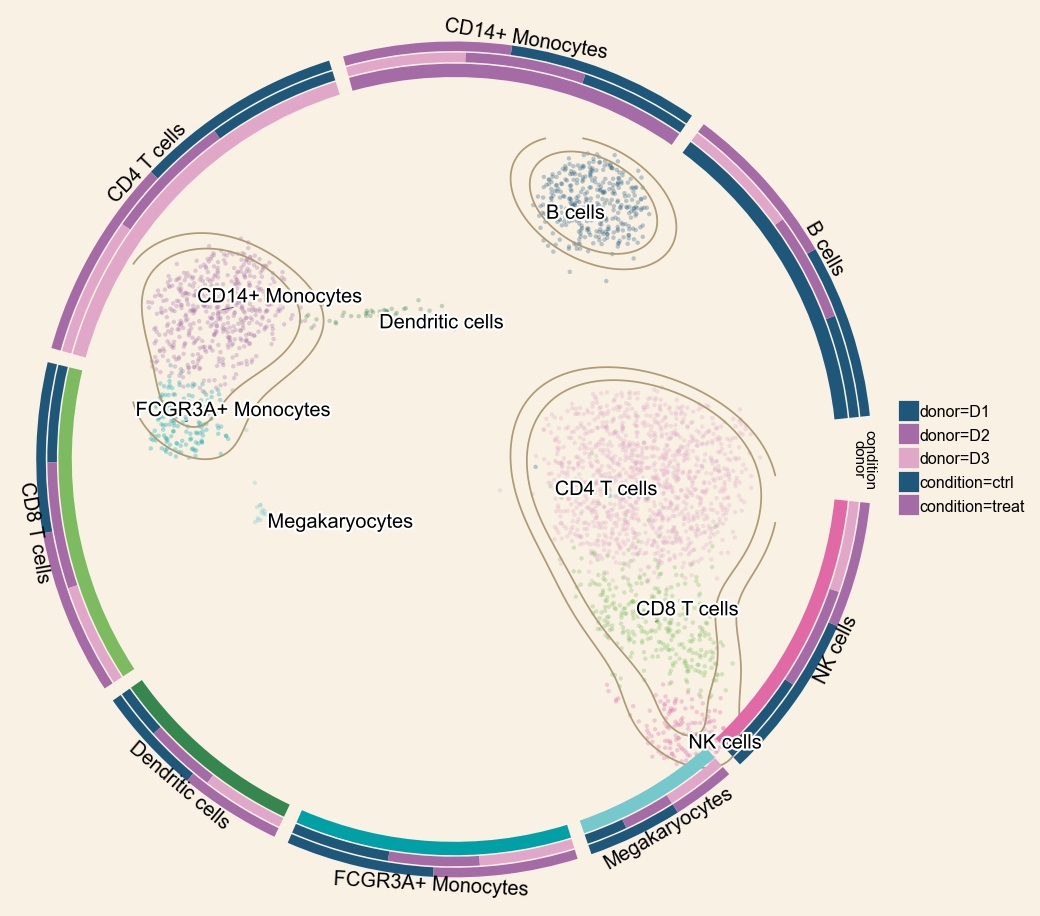

<Axes: >

In [3]:
ov.pl.plot1cell(
    adata_small, clusters='louvain', basis='X_umap',
    tracks=['donor', 'condition'],
    point_size=4, figsize=(7, 7),
)


## Case B — Medium scale (23 cell types)

**[Tabula Sapiens — Pancreas](https://cellxgene.cziscience.com/datasets/) from CELLxGENE**:
14 140 cells × 23 cell types. This is the kind of dataset where
the R `plot1cell` tangent labels start to collide — the
Python port automatically switches to radial labels because
`n_clusters > 10`, so every cell type stays readable as a
spoke around the ring.

Download (~700 MB) happens once and is cached on disk. If you
already have the file locally, just point `URL` at it.


In [4]:
import os, urllib.request
URL = 'https://datasets.cellxgene.cziscience.com/4be7951a-4ae7-4a81-86f1-e2649b304d1c.h5ad'
CACHE = 'data/ts_pancreas.h5ad'
os.makedirs('data', exist_ok=True)
if not os.path.exists(CACHE):
    print('downloading Tabula Sapiens Pancreas...'); urllib.request.urlretrieve(URL, CACHE)


In [5]:
adata_med = sc.read_h5ad(CACHE)
# Keep only the columns we need for plotting — the raw h5ad is
# large because it ships with full counts; we just need the UMAP
# embedding and a handful of obs columns.
adata_med = adata_med[:, :200].copy()   # trim var axis
adata_med.obs['cell_type'] = adata_med.obs['cell_type'].astype('category')
print(adata_med.shape, '| n_celltypes =', adata_med.obs['cell_type'].nunique())


(14140, 200) | n_celltypes = 23


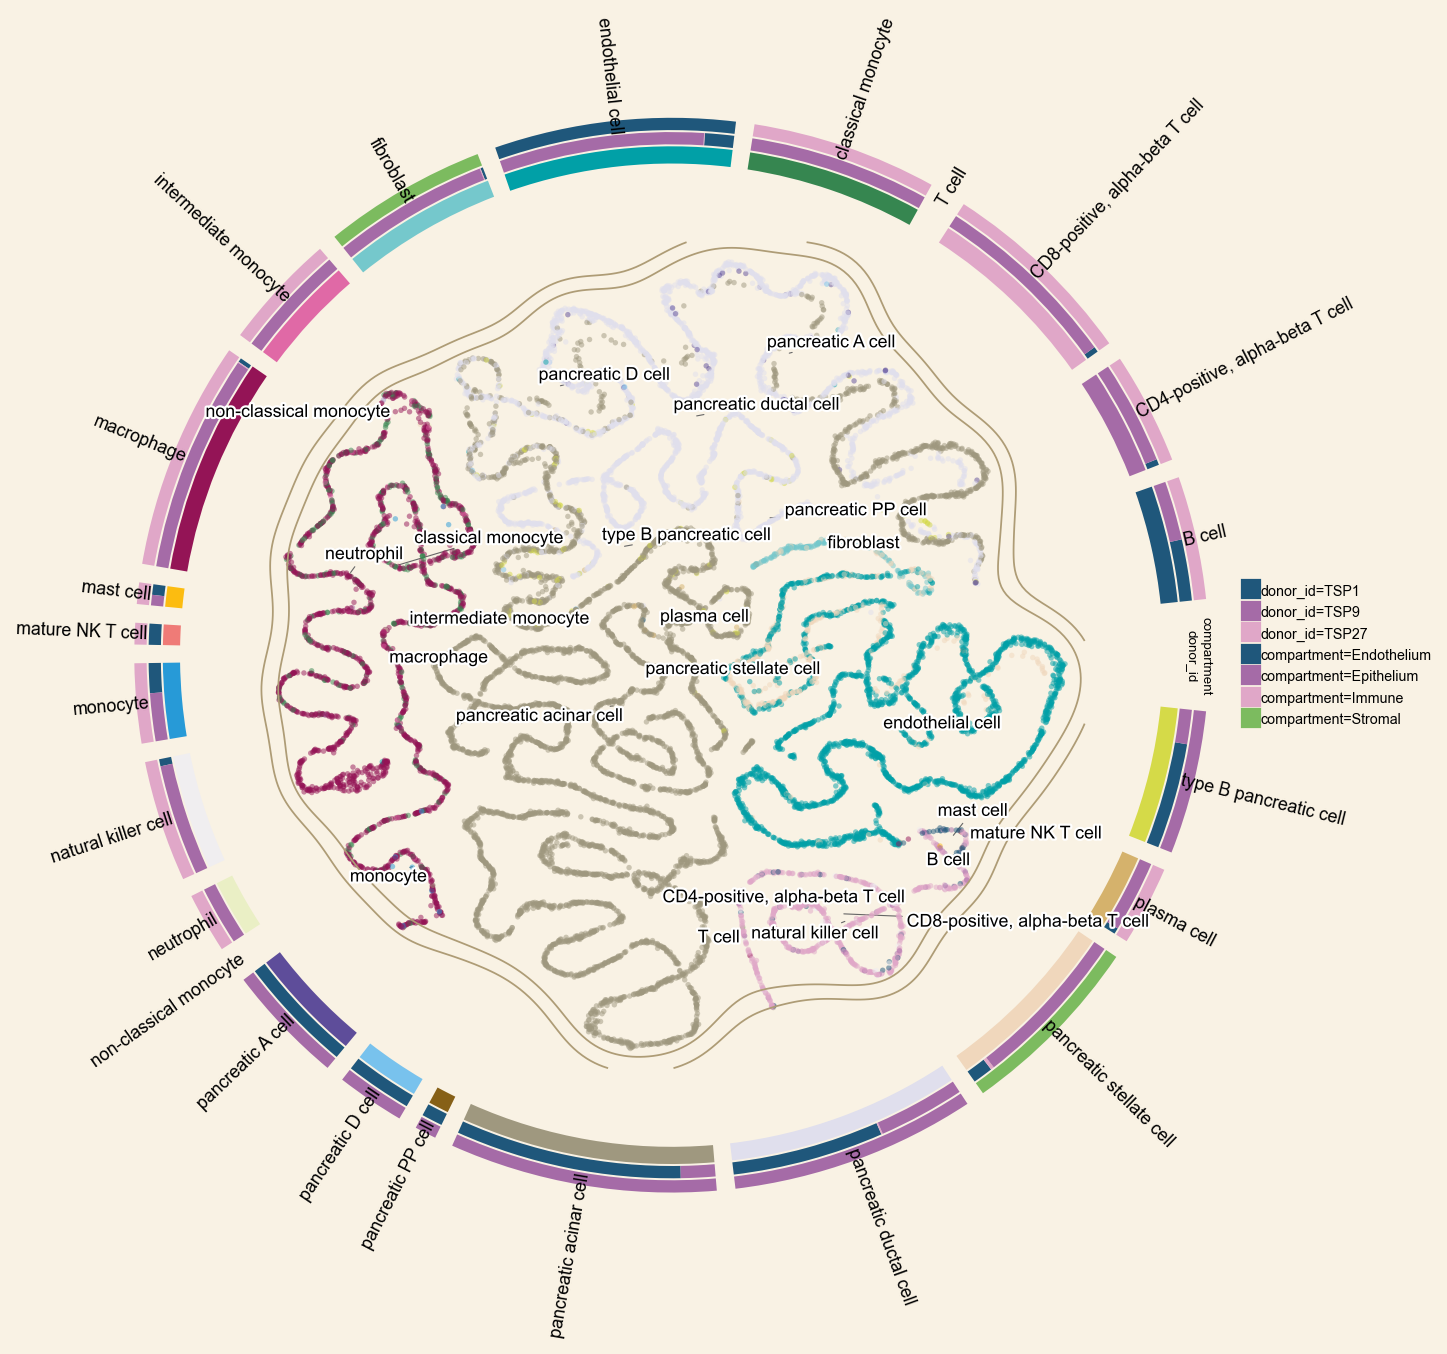

<Axes: >

In [6]:
ov.pl.plot1cell(
    adata_med, clusters='cell_type', basis='X_umap',
    tracks=['donor_id', 'compartment'],
    point_size=6, point_alpha=0.5,
    figsize=(9, 9), label_fontsize=8,
)


## Key parameters

| Parameter | Purpose |
|-----------|---------|
| `clusters` | obs column with the cluster label (required). |
| `basis` | obsm key, default `'X_umap'`. |
| `tracks` | list of obs columns → one concentric ring each, coloured by the run-length composition within each cluster sector. |
| `coord_scale` | how much of the unit circle the scatter fills (0–1). |
| `contour_levels` | KDE levels to overlay; `None` disables. |
| `label_orient` | `'auto'` (default) \| `'tangent'` \| `'radial'`. Auto uses tangent for ≤10 clusters (classic R look) and radial above that so labels never overlap. |
| `gap_between_deg`, `gap_start_deg` | angular gaps between sectors (2°) and at the start of the circle (12°) — match the R convention. |
| `cluster_palette`, `track_palette` | override the default `ov` palette. Accepts a colormap name or a list of colors. |
| `bg_color` | canvas colour (default the R parchment `'#F9F2E4'`). Use `'white'` for a plain look. |
| `return_data=True` | also return the per-cell dataframe used internally, useful for reproducing or extending the figure manually. |


## Custom styling

Pure matplotlib underneath — anything you do to `Axes` still
works. A plain-white variant with a `tab10` palette:


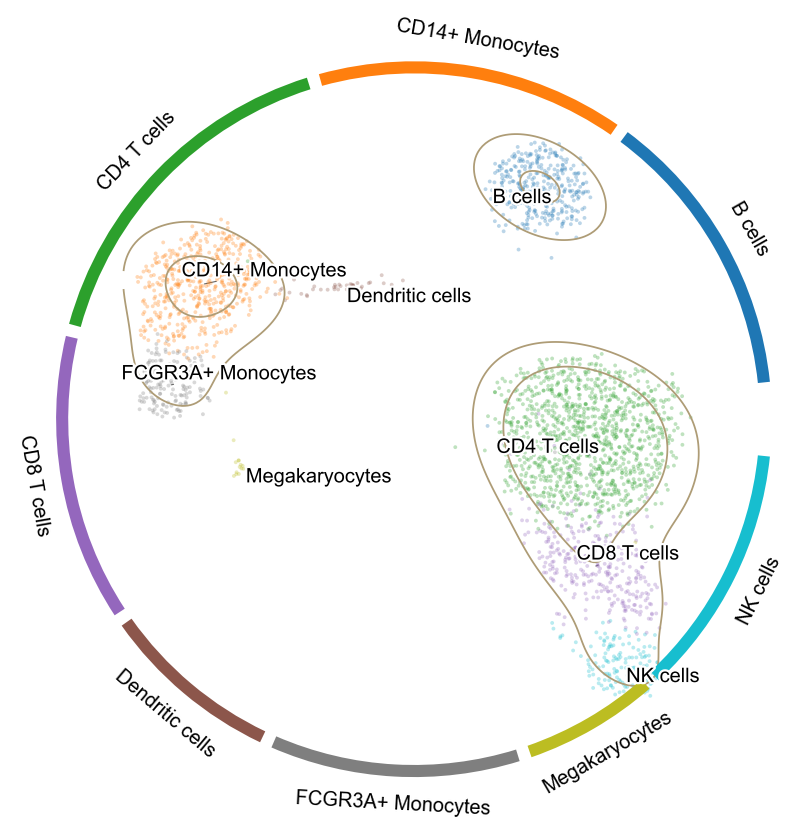

<Axes: >

In [7]:
ov.pl.plot1cell(
    adata_small, clusters='louvain', basis='X_umap',
    tracks=None,
    cluster_palette='tab10',
    contour_levels=(0.25, 0.5),
    bg_color='white',
    point_size=3, figsize=(6, 6),
)
